# Enterprise Consumer Complaint Intelligence Platform

#### Project Overview

Financial institutions receive thousands of consumer complaints every day across multiple financial products such as credit cards, mortgages, student loans, checking accounts, and debt collection services. Manually reviewing and routing these complaints to the appropriate business teams is time-consuming, expensive, and prone to delays.

This project develops an **Enterprise Consumer Complaint Intelligence Platform** that automatically analyzes complaint narratives and performs intelligent multi-stage classification using Natural Language Processing (NLP).

The platform first predicts the financial product associated with a complaint. Based on the predicted product, it dynamically routes the complaint to a specialized issue classification model trained specifically for that product. This hierarchical architecture improves classification accuracy while closely reflecting real-world enterprise complaint routing systems.

To improve production reliability, the platform incorporates a confidence-based rejection mechanism that identifies low-confidence predictions and labels them as **Unknown**, preventing potentially incorrect routing of unrelated complaints. Additionally, an explainability component identifies the most influential words contributing to each prediction, increasing model transparency and interpretability.

The project demonstrates an end-to-end NLP pipeline including text preprocessing, feature engineering, supervised machine learning, confidence-based prediction validation, explainable AI, and model serialization for deployment.

#### Machine Learning Pipeline
The dataset contains genuine consumer complaints, making it highly suitable for developing enterprise-scale NLP classification systems.
| Feature | Purpose |
|----------|---------|
| Consumer Complaint Narrative | Model Input |
| Product | Target Variable (Stage 1) |
| Issue | Target Variable (Stage 2) |


                     Consumer Complaint
                              │
                              ▼
                     Text Preprocessing
                              │
                              ▼
                     TF-IDF Vectorization
                              │
                              ▼
                Product Classification Model
                       (LinearSVC)
                              │
                              ▼
               Confidence Evaluation Layer
                    │                   │
                    │                   │
              Low Confidence      High Confidence
                    │                   │
                    ▼                   ▼
               Unknown Complaint   Product Prediction
                                         │
                                         ▼
                           Product-Specific Issue Model
                                         │
                                         ▼
                                 Issue Prediction
                                         │
                                         ▼
                              Explainable AI (Top Words)
                                         │
                                         ▼
                                 Final Prediction

## 1. Imports

In [5]:
# Standard Python Libraries
import re, string, json, joblib
import warnings
warnings.filterwarnings("ignore")

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Natural Language Processing
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Uncomment only during first execution
# nltk.download("punkt")
# nltk.download("stopwords")
# nltk.download("wordnet")

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

## 2. Load Dataset

In [7]:
# Load dataset
df = pd.read_csv(compliants.csv)

In [8]:
df.shape

(15622, 12)

In [9]:
df.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company,State,Date sent to company,Company response to consumer,Timely response?,Complaint ID
0,2025-04-07T03:46:02.000Z,Student loan,Federal student loan servicing,Dealing with your lender or servicer,Problem with customer service,I am filing this complaint regarding an admini...,MOHELA,IL,2025-04-07T03:50:40.000Z,Closed with explanation,No,12851157
1,2025-04-14T15:18:49.000Z,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account information incorrect,I am writing to you not just as XXXX of the XX...,MOHELA,GA,2025-04-14T15:49:32.000Z,Closed with explanation,No,12972377
2,2025-05-21T03:56:02.000Z,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Personal information incorrect,On XX/XX/year> I received a notification from ...,MOHELA,ME,2025-05-21T04:11:49.000Z,Closed with explanation,No,13609314
3,2025-05-21T18:03:53.000Z,Student loan,Federal student loan servicing,Struggling to repay your loan,"Problem with forgiveness, cancellation, or dis...","To Whom It May Concern, I am filing a a formal...",MOHELA,CA,2025-05-21T18:37:19.000Z,Closed with explanation,No,13641471
4,2025-08-17T01:15:29.000Z,Mortgage,Conventional home mortgage,Applying for a mortgage or refinancing an exis...,Loan estimate or other related disclosures,"Dear all, My name is XXXX XXXX, my address is ...","RESCO, INC.",HI,2026-05-04T13:13:09.000Z,Closed with explanation,Yes,21848458


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15622 entries, 0 to 15621
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   Date received                 15622 non-null  str  
 1   Product                       15622 non-null  str  
 2   Sub-product                   15622 non-null  str  
 3   Issue                         15622 non-null  str  
 4   Sub-issue                     13764 non-null  str  
 5   Consumer complaint narrative  15622 non-null  str  
 6   Company                       15622 non-null  str  
 7   State                         15523 non-null  str  
 8   Date sent to company          15622 non-null  str  
 9   Company response to consumer  14918 non-null  str  
 10  Timely response?              15622 non-null  str  
 11  Complaint ID                  15622 non-null  int64
dtypes: int64(1), str(11)
memory usage: 24.7 MB


## 3. Data Cleaning

In [12]:
date_cols = [
    'Date received',
    'Date sent to company'
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col])

df["Date received"] = df["Date received"].dt.tz_localize(None)
df["Date sent to company"] = df["Date sent to company"].dt.tz_localize(None)

In [13]:
df.isnull().sum()

Date received                      0
Product                            0
Sub-product                        0
Issue                              0
Sub-issue                       1858
Consumer complaint narrative       0
Company                            0
State                             99
Date sent to company               0
Company response to consumer     704
Timely response?                   0
Complaint ID                       0
dtype: int64

In [14]:
df['Sub-issue'] = df['Sub-issue'].fillna('Unknown')
df['Company response to consumer'] = df['Company response to consumer'].fillna('Unknown')
df['State'] = df['State'].fillna('Unknown')

In [15]:
# ==========================================================
# Dataset Quality Summary
# ==========================================================

quality_summary = pd.DataFrame({
    "Metric": [
        "Total Records",
        "Total Columns",
        "Duplicate Records",
        "Columns with Missing Values"
    ],
    "Value": [
        len(df),
        df.shape[1],
        df.duplicated().sum(),
        (df.isnull().sum() > 0).sum()
    ]
})

quality_summary

,Metric,Value
0,Total Records,15622
1,Total Columns,12
2,Duplicate Records,0
3,Columns with Missing Values,0


In [16]:
# Create stop word set
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

print("Total stopwords before customizing:", len(stop_words))

# Add custom words
custom_stopwords =  ['xxxx', 'xxxxxxxx']
stop_words.update(custom_stopwords)

print("Total stopwords after customizing:", len(stop_words))

def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Remove email addresses
    text = re.sub(r"\S+@\S+", " ", text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Remove long numbers (account numbers, phone numbers, etc.)
    text = re.sub(r"\b\d{5,}\b", " ", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenization
    words = text.split()

    # Stopword removal + Lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

Total stopwords before customizing: 198
Total stopwords after customizing: 200


In [17]:
# Apply Cleaning

df["Clean_Text"] = df["Consumer complaint narrative"].apply(clean_text)

In [18]:
# Remove Empty Documents
df = df[df["Clean_Text"].str.strip() != ""]

#### Text Cleaning Summary

The preprocessing pipeline successfully transformed raw complaint narratives into standardized text suitable for machine learning.

Key outcomes include:

- Removed irrelevant textual noise.
- Standardized vocabulary through lowercase conversion.
- Reduced feature space using stopword removal.
- Improved semantic consistency using lemmatization.
- Generated a reusable preprocessing pipeline that can be applied consistently during both model training and inference.

The cleaned complaint narratives are now ready for exploratory analysis and TF-IDF feature engineering.

Our target features are Product and Issue; we’ll review them further.

In [20]:
# Verify unique Products
print(f"Unique Products : {df['Product'].nunique():,}")

product_counts = df['Product'].value_counts()
product_counts

Unique Products : 12


Product
Debt collection                                                                 5022
Credit card                                                                     2790
Checking or savings account                                                     2766
Money transfer, virtual currency, or money service                              1197
Mortgage                                                                        1001
Credit reporting or other personal consumer reports                              856
Vehicle loan or lease                                                            746
Payday loan, title loan, personal loan, or advance loan                          508
Student loan                                                                     413
Prepaid card                                                                     180
Debt or credit management                                                        135
Credit reporting, credit repair services, or other person

In [21]:
# Verify Unique issues
print(f"Unique Issue Categories : {df['Issue'].nunique():,}")

issue_counts = df['Issue'].value_counts()
issue_counts

Unique Issue Categories : 85


Issue
Attempts to collect debt not owed                                2591
Managing an account                                              1516
Problem with a purchase shown on your statement                   989
Written notification about debt                                   937
Incorrect information on your report                              740
                                                                 ... 
Overdraft, savings, or rewards features                             2
Problem with a company's investigation into an existing issue       1
Disclosure verification of debt                                     1
Advertising                                                         1
Problem with overdraft                                              1
Name: count, Length: 85, dtype: int64

## 4. NLP Features

In [23]:
df['Word_Count'] = (
    df['Clean_Text']
    .str.split()
    .str.len()
)

In [24]:
df.head(2)

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company,State,Date sent to company,Company response to consumer,Timely response?,Complaint ID,Clean_Text,Word_Count
0,2025-04-07 03:46:02,Student loan,Federal student loan servicing,Dealing with your lender or servicer,Problem with customer service,I am filing this complaint regarding an admini...,MOHELA,IL,2025-04-07 03:50:40,Closed with explanation,No,12851157,filing complaint regarding administrative erro...,159
1,2025-04-14 15:18:49,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account information incorrect,I am writing to you not just as XXXX of the XX...,MOHELA,GA,2025-04-14 15:49:32,Closed with explanation,No,12972377,writing borrower identified investigation sing...,161


In [25]:
# Top Words
from collections import Counter

all_words = " ".join(df["Clean_Text"]).split()

word_counts = Counter(all_words)

top_words = pd.DataFrame(
    word_counts.most_common(20),
    columns=["Word","Frequency"]
)

top_words

,Word,Frequency
0,account,41167
1,credit,23858
2,payment,16243
3,debt,14301
4,reporting,11698
5,bank,11360
6,information,11125
7,report,9582
8,dispute,9448
9,transaction,8396


In [26]:
# Bi gram

from sklearn.feature_extraction.text import CountVectorizer

bigram_vectorizer = CountVectorizer(
    ngram_range=(2,2),
    stop_words="english",
    max_features=20
)

X_bigram = bigram_vectorizer.fit_transform(df["Clean_Text"])

bigram_counts = X_bigram.sum(axis=0).A1

bigram_df = pd.DataFrame({
    "Bigram": bigram_vectorizer.get_feature_names_out(),
    "Count": bigram_counts
})

bigram_df = bigram_df.sort_values(
    by="Count",
    ascending=False
)

bigram_df

,Bigram,Count
9,credit report,4154
10,credit reporting,4067
0,15 usc,3643
8,credit card,2865
13,fair credit,2498
3,bank america,1989
6,complaint regarding,1901
14,filing complaint,1892
17,reporting act,1817
2,alleged debt,1786


In [27]:
# Most Frequent Trigram

trigram_vectorizer = CountVectorizer(
    ngram_range=(3,3),
    stop_words="english",
    max_features=20
)

X_tri = trigram_vectorizer.fit_transform(df["Clean_Text"])

tri_counts = X_tri.sum(axis=0).A1

tri_df = pd.DataFrame({
    "Trigram": trigram_vectorizer.get_feature_names_out(),
    "Count": tri_counts
})

tri_df = tri_df.sort_values(
    by="Count",
    ascending=False
)

tri_df

,Trigram,Count
10,fair credit reporting,1819
7,credit reporting act,1811
9,debt collection practice,1310
11,fair debt collection,1251
12,falsely reporting credit,1247
2,collection practice act,1245
8,credit reporting agency,1004
13,filing complaint regarding,907
16,reporting act fcra,862
17,reporting credit account,832


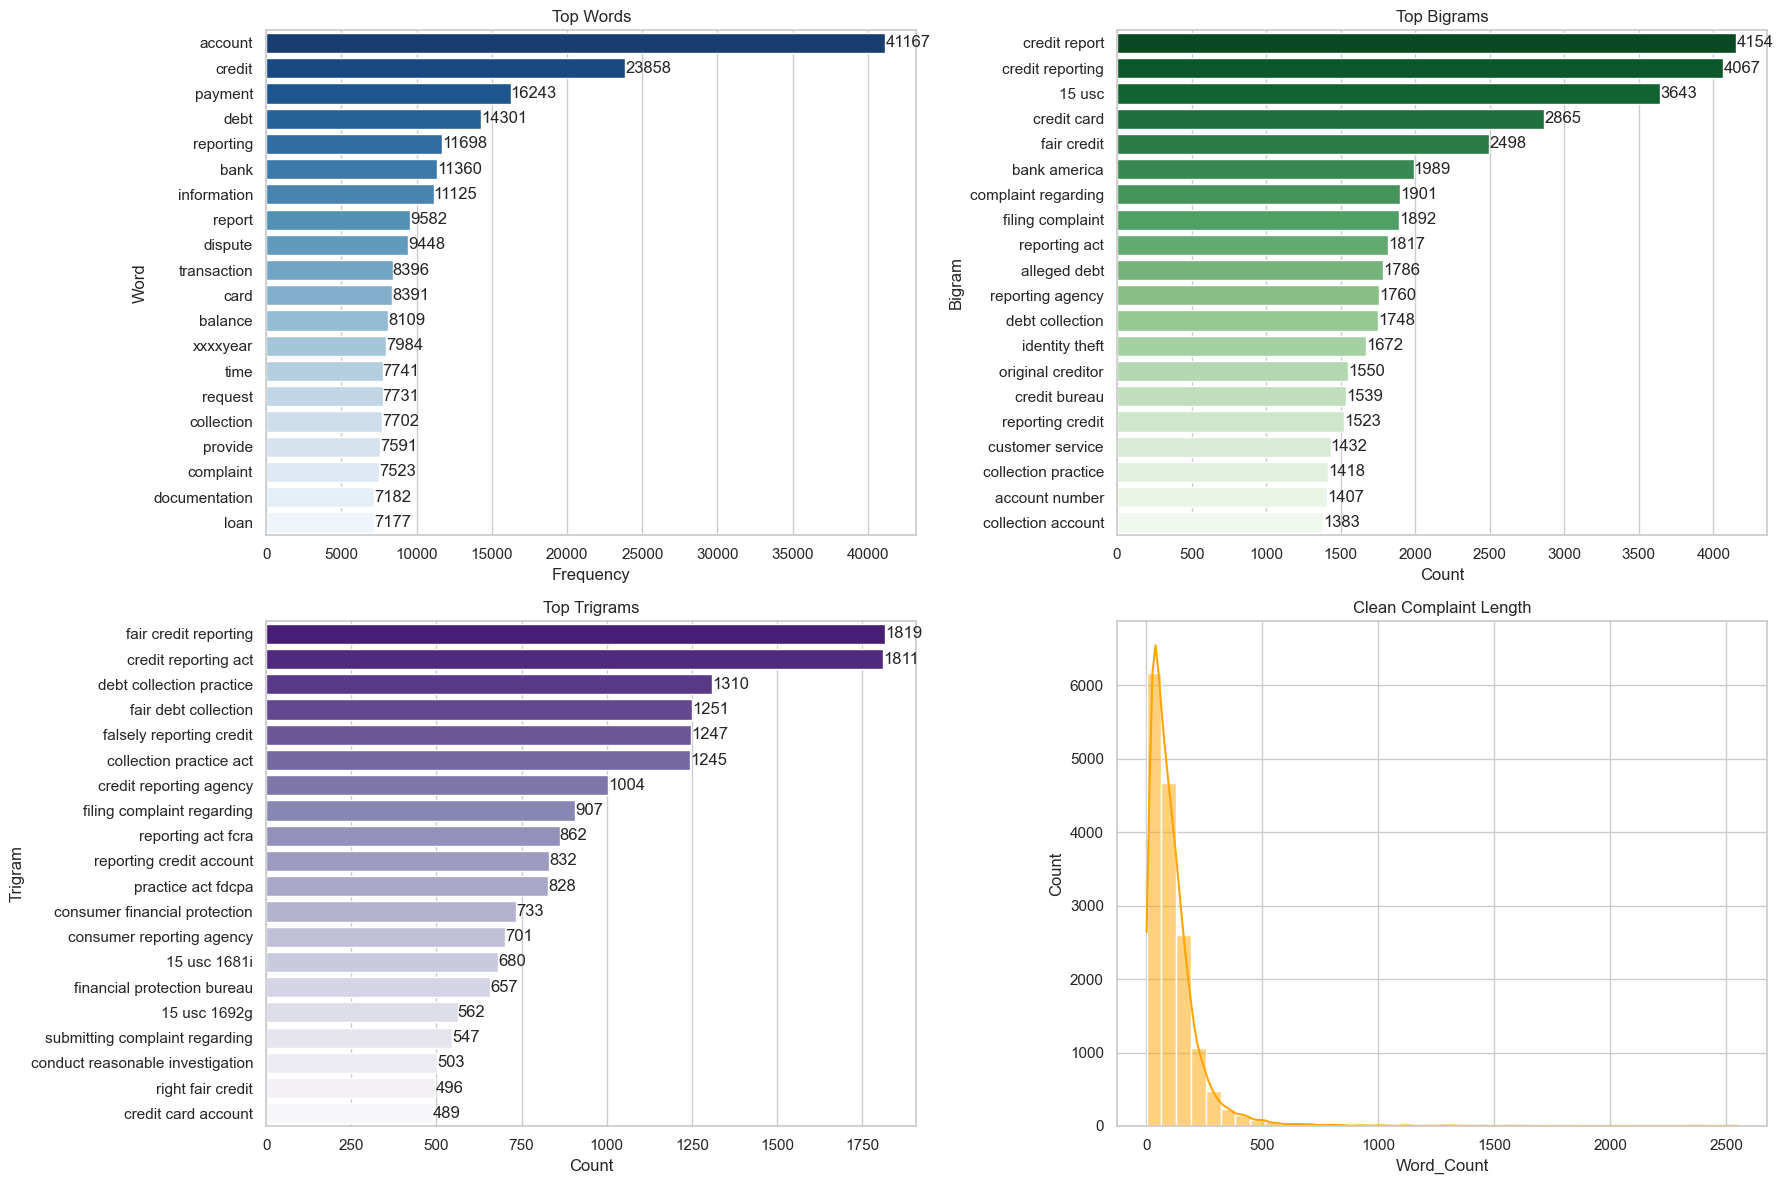

In [28]:
# Visualization - Top words,Bigram,Trigram,word count distribution

import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1️⃣ Top Words (sorted descending)
top_words_sorted = top_words.sort_values("Frequency", ascending=False)
sns.barplot(
    data=top_words_sorted,
    x="Frequency",
    y="Word",
    ax=axes[0,0],
    palette="Blues_r"
)
axes[0,0].set_title("Top Words")
for i, v in enumerate(top_words_sorted["Frequency"]):
    axes[0,0].text(v + 0.5, i, str(v), va="center")

# 2️⃣ Top Bigrams
bigram_sorted = bigram_df.sort_values("Count", ascending=False)
sns.barplot(
    data=bigram_sorted,
    x="Count",
    y="Bigram",
    ax=axes[0,1],
    palette="Greens_r"
)
axes[0,1].set_title("Top Bigrams")
for i, v in enumerate(bigram_sorted["Count"]):
    axes[0,1].text(v + 0.5, i, str(v), va="center")

# 3️⃣ Top Trigrams
tri_sorted = tri_df.sort_values("Count", ascending=False)
sns.barplot(
    data=tri_sorted,
    x="Count",
    y="Trigram",
    ax=axes[1,0],
    palette="Purples_r"
)
axes[1,0].set_title("Top Trigrams")
for i, v in enumerate(tri_sorted["Count"]):
    axes[1,0].text(v + 0.5, i, str(v), va="center")

# 4️⃣ Clean Complaint Length
sns.histplot(
    data=df,
    x="Word_Count",
    bins=40,
    kde=True,
    ax=axes[1,1],
    color="orange"
)
axes[1,1].set_title("Clean Complaint Length")

plt.tight_layout()
plt.show()


In [29]:
# Monthly Analysis 
monthly = (
    df.groupby(
        pd.Grouper(key="Date received", freq="ME")
    )
    .size()
    .reset_index(name="Complaints")
)

monthly.head()

,Date received,Complaints
0,2016-01-31,1
1,2016-02-29,0
2,2016-03-31,0
3,2016-04-30,0
4,2016-05-31,0


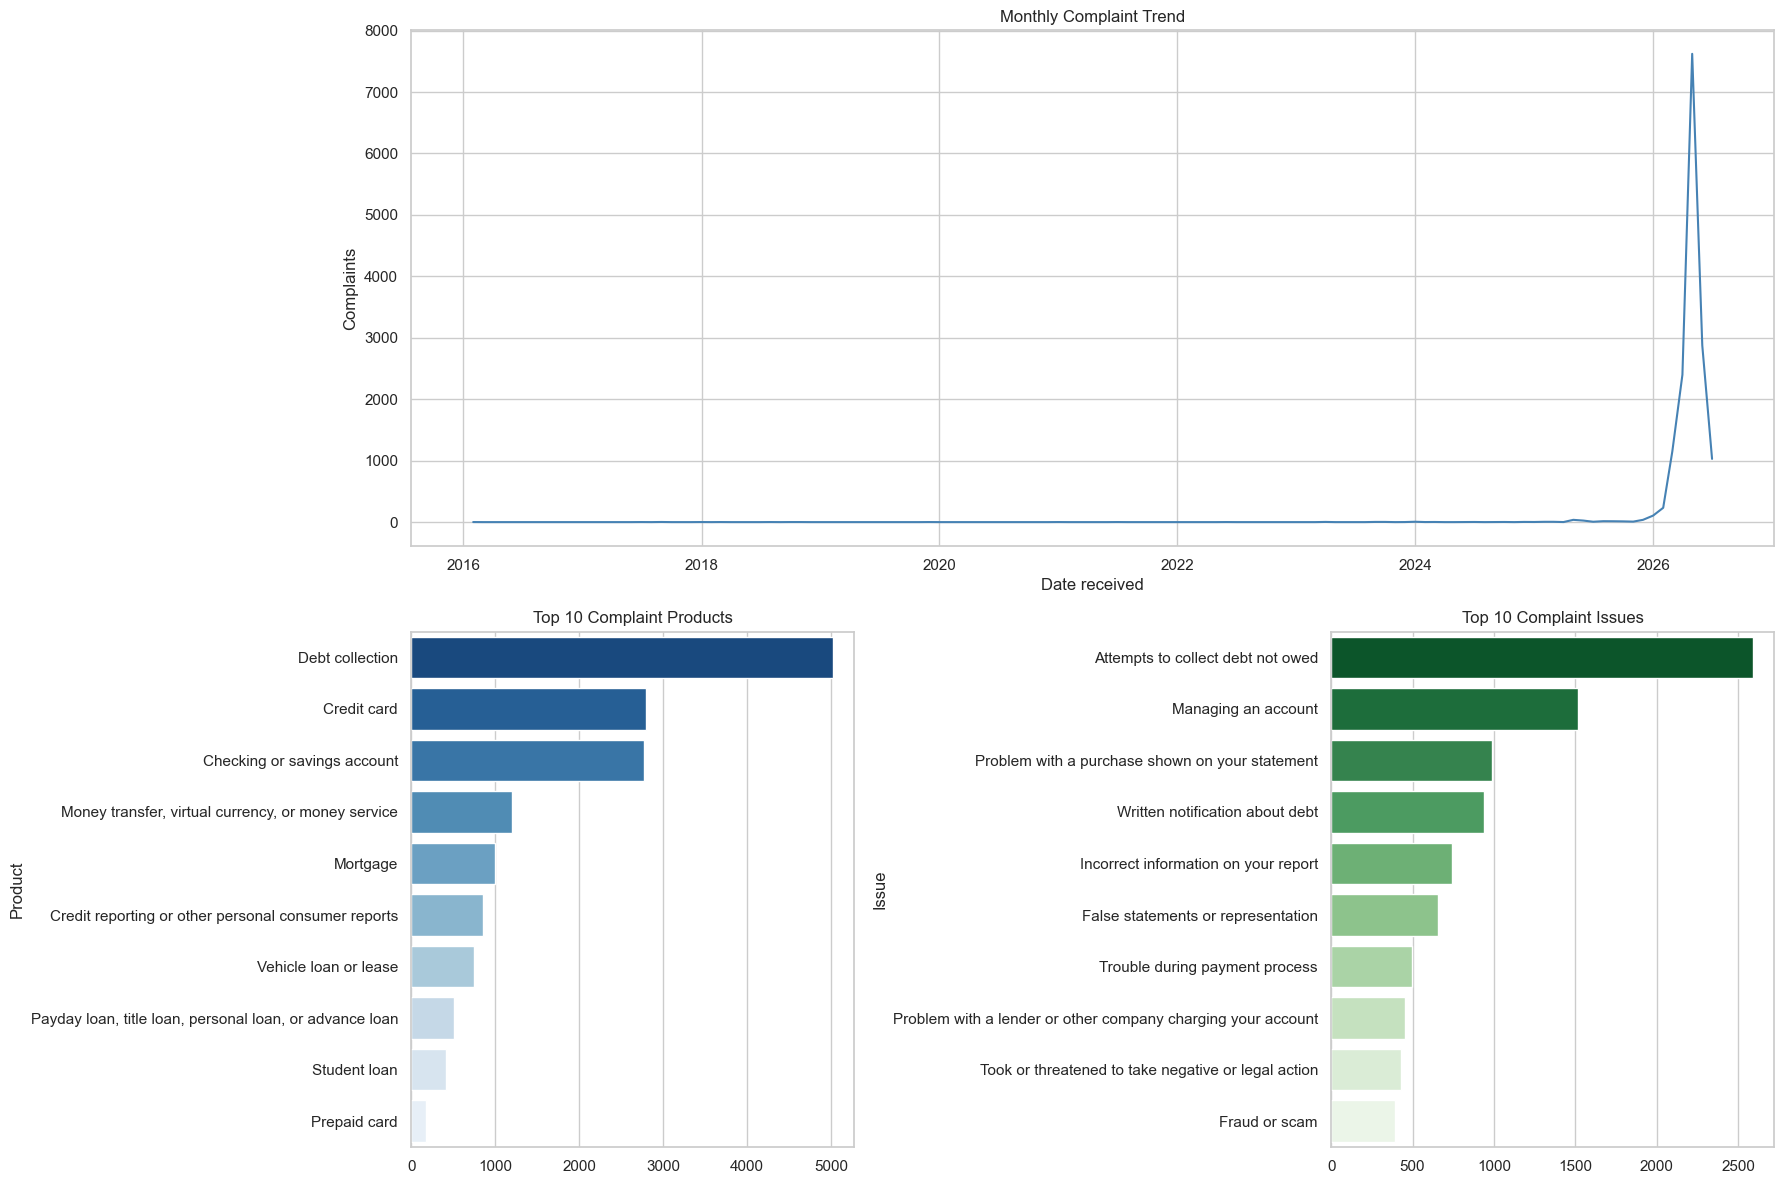

In [30]:
# Visualization: Top Products & Issues
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

# Create a figure with GridSpec layout
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(2, 2)  # 2 rows, 2 columns

# 1️⃣ Monthly Complaint Trend (spans entire first row)
ax1 = fig.add_subplot(gs[0, :])  # span all columns in row 0
sns.lineplot(
    data=monthly,
    x="Date received",
    y="Complaints",
    ax=ax1,
    color="steelblue"
)
ax1.set_title("Monthly Complaint Trend")

# 2️⃣ Top Products (bottom-left)
ax2 = fig.add_subplot(gs[1, 0])
top_products = df["Product"].value_counts().head(10)
sns.barplot(
    x=top_products.values,
    y=top_products.index,
    ax=ax2,
    palette="Blues_r"
)
ax2.set_title("Top 10 Complaint Products")

# 3️⃣ Top Issues (bottom-right)
ax3 = fig.add_subplot(gs[1, 1])
top_issues = df["Issue"].value_counts().head(10)
sns.barplot(
    x=top_issues.values,
    y=top_issues.index,
    ax=ax3,
    palette="Greens_r"
)
ax3.set_title("Top 10 Complaint Issues")

plt.tight_layout()
plt.show()


#### Product Classification Model
This is a **multi-class text classification** problem.Model - Intelligent Product Routing enterprise complaint routing system first identifies the product area (e.g., credit card, mortgage, debt collection) and then classifies the specific issue within that product.
- Input: Cleaned Consumer Complaint Narrative
- Target: Product

#### Machine Learning Algorithm
- Linear Support Vector Classifier (LinearSVC)

#### Feature Engineering
- TF-IDF Vectorization

The objective is to accurately classify each complaint into its corresponding financial product.

#### Train-Test Split

The dataset is divided into training and testing subsets.

- **Training Set (80%)**: Used to train the classifier.
- **Testing Set (20%)**: Used to evaluate the model on previously unseen complaint narratives.

A fixed random state is used to ensure reproducibility.

Why stratify=y?
Because product classes are imbalanced. Stratification preserves the product distribution in both training and testing sets.

#### TF-IDF Feature Engineering

Machine learning algorithms cannot directly process raw text.

TF-IDF (Term Frequency–Inverse Document Frequency) converts complaint narratives into numerical feature vectors by assigning higher importance to words that are frequent within a complaint but relatively uncommon across the entire corpus.

This representation effectively captures the distinguishing vocabulary of different financial products while reducing the influence of common words.



## 5. Product Model Training

In [34]:
# Train-Test Split
X=df['Clean_Text']
y=df['Product']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

print(f"Training Samples : {len(X_train):,}")
print(f"Testing Samples  : {len(X_test):,}")

# TF-IDF Feature Engineering
product_vectorizer=TfidfVectorizer(max_features=10000,ngram_range=(1,2),min_df=2,max_df=0.95,sublinear_tf=True)

X_train_tfidf=product_vectorizer.fit_transform(X_train)
X_test_tfidf=product_vectorizer.transform(X_test)

print("\n TF-IDF Feature Statistics: ")
print(f"Vocabulary Size      : {len(product_vectorizer.vocabulary_):,}")
print(f"Training Matrix Shape: {X_train_tfidf.shape}")
print(f"Testing Matrix Shape : {X_test_tfidf.shape}")

# Train Product Classification Model
product_model =LinearSVC(random_state=42)
product_model.fit(X_train_tfidf,y_train)

# Generate Predictions
product_predictions =product_model.predict(X_test_tfidf)

Training Samples : 12,496
Testing Samples  : 3,125

 TF-IDF Feature Statistics: 
Vocabulary Size      : 10,000
Training Matrix Shape: (12496, 10000)
Testing Matrix Shape : (3125, 10000)


In [35]:
# Train-Test Split
train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["Product"]
)

print(f"Training Samples : {len(train_df):,}")
print(f"Testing Samples  : {len(test_df):,}")

X_train = train_df["Clean_Text"]
y_train = train_df["Product"]

X_test = test_df["Clean_Text"]
y_test = test_df["Product"]

# TF-IDF Feature Engineering
product_vectorizer=TfidfVectorizer(max_features=10000,ngram_range=(1,2),min_df=2,max_df=0.95,sublinear_tf=True)

X_train_tfidf=product_vectorizer.fit_transform(X_train)
X_test_tfidf=product_vectorizer.transform(X_test)

print("\n TF-IDF Feature Statistics: ")
print(f"Vocabulary Size      : {len(product_vectorizer.vocabulary_):,}")
print(f"Training Matrix Shape: {X_train_tfidf.shape}")
print(f"Testing Matrix Shape : {X_test_tfidf.shape}")

# Train Product Classification Model
product_model =LinearSVC(random_state=42)
product_model.fit(X_train_tfidf,y_train)

# Generate Predictions
product_predictions =product_model.predict(X_test_tfidf)

Training Samples : 12,496
Testing Samples  : 3,125

 TF-IDF Feature Statistics: 
Vocabulary Size      : 10,000
Training Matrix Shape: (12496, 10000)
Testing Matrix Shape : (3125, 10000)


| Parameter           |                         Value | Reason                                          |
| ------------------- | ----------------------------: | ----------------------------------------------- |
| `max_features`      |                          5000 | Controls vocabulary size and memory usage       |
| `ngram_range=(1,2)` |            Unigrams + Bigrams | Captures common phrases such as "credit card"   |
| `min_df=5`          |        Ignore very rare terms | Reduces noise                                   |
| `max_df=0.95`       | Ignore extremely common terms | Removes overly frequent, less informative words |
| `sublinear_tf=True` |      Log-scale term frequency | Often improves linear model performance         |


#### Reasons for selecting LinearSVC

- Performs exceptionally well on high-dimensional sparse TF-IDF features.
- Efficient for large text classification datasets.
- Faster training than kernel-based Support Vector Machines.
- Lower memory consumption compared to many alternative classifiers.
- Produces robust decision boundaries for multi-class text classification.
- Supports model interpretability through feature coefficients, enabling explainable AI.

Although LinearSVC does not directly produce probability estimates, its decision scores are utilized to implement a confidence-based rejection mechanism for identifying low-confidence predictions.

In [38]:
# ==========================================================
# Actual vs Predicted Product
# ==========================================================

prediction_results = pd.DataFrame({
    "Original Complaint": df.loc[X_test.index, "Consumer complaint narrative"],
    "Cleaned Complaint": X_test,
    "Actual Product": y_test,
    "Predicted Product": product_predictions
})

# Add Prediction Status
prediction_results["Prediction Status"] = np.where(
    prediction_results["Actual Product"] ==
    prediction_results["Predicted Product"],
    "Correct",
    "Incorrect"
)

prediction_results.head(10)

,Original Complaint,Cleaned Complaint,Actual Product,Predicted Product,Prediction Status
8278,I would like to report that there is incorrect...,would like report incorrect information credit...,Credit reporting or other personal consumer re...,Credit reporting or other personal consumer re...,Correct
12706,I am writing to report that my Social Security...,writing report social security number compromi...,Debt or credit management,Debt collection,Incorrect
4557,XX/XX/year> Radius Global Solutions reported t...,xxxxyear radius global solution reported credi...,Debt collection,Debt collection,Correct
995,Company : Transworld Systems Inc. \nAccount Na...,company transworld system inc account name rep...,Debt collection,Debt collection,Correct
2039,On XX/XX/XXXXXXXX I purchased a used vehicle ...,xxxxxxxxxxxx purchased used vehicle performanc...,Vehicle loan or lease,Vehicle loan or lease,Correct
8756,A return from XXXX XXXX was returned on XX/XX...,return returned xxxxyear 7400 merchant stated ...,Checking or savings account,Checking or savings account,Correct
3437,Subject : Wire transfer fraud funds appear to ...,subject wire transfer fraud fund appear held b...,"Money transfer, virtual currency, or money ser...","Money transfer, virtual currency, or money ser...",Correct
681,Sallie Mae calls several times daily to collec...,sallie mae call several time daily collect pay...,Debt collection,Student loan,Incorrect
1675,""" I am filing this complaint regarding a lost ...",filing complaint regarding lost paper consolid...,Student loan,Student loan,Correct
2166,I received a check in the mail for {$800.00} w...,received check mail 80000 stated cashed would ...,"Payday loan, title loan, personal loan, or adv...",Mortgage,Incorrect


In [39]:
prediction_summary = (
    prediction_results["Prediction Status"]
    .value_counts()
    .rename_axis("Status")
    .reset_index(name="Count")
)

prediction_summary

,Status,Count
0,Correct,2545
1,Incorrect,580


This comparison provides several benefits:

Verifies predictions on individual samples.
Highlights misclassifications for further analysis.
Creates a bridge to the confusion matrix and classification report.
Demonstrates that you're evaluating the model beyond a single accuracy metric.

#### Model Evaluation

Model evaluation determines how well the product classifier generalizes to previously unseen consumer complaints.

A comprehensive evaluation includes:
- Overall accuracy
- Product-wise performance
- Confusion matrix
- Error analysis

Rather than relying on a single metric, multiple evaluation techniques provide a complete understanding of the classifier's strengths and limitations.

In [42]:
# ==========================================================
# Overall Model Accuracy
# ==========================================================

product_accuracy = accuracy_score(
    y_test,
    product_predictions
)

print("=" * 60)
print("Product Classification Performance")
print("=" * 60)
print(f"Accuracy : {product_accuracy:.4f}")

Product Classification Performance
Accuracy : 0.8144


In [43]:
# ==========================================================
# Product-classification report
# ==========================================================

report = classification_report(
    y_test,
    product_predictions,
    output_dict=True
)

product_performance = (
    pd.DataFrame(report)
    .transpose()
    .round(3)
)

product_performance

,precision,recall,f1-score,support
Checking or savings account,0.737,0.799,0.767,553.000
Credit card,0.785,0.832,0.808,558.000
Credit reporting or other personal consumer reports,0.813,0.789,0.801,171.000
"Credit reporting, credit repair services, or other personal consumer reports",0.000,0.000,0.000,1.000
Debt collection,0.892,0.915,0.904,1005.000
Debt or credit management,1.000,0.148,0.258,27.000
"Money transfer, virtual currency, or money service",0.679,0.617,0.646,240.000
Mortgage,0.934,0.920,0.927,200.000
"Payday loan, title loan, personal loan, or advance loan",0.628,0.480,0.544,102.000
Prepaid card,0.583,0.194,0.292,36.000


#### Interpretation

The classification report provides detailed performance metrics for each financial product.

**Precision**

Measures how many complaints predicted for a product actually belong to that product.

**Recall**

Measures how many actual complaints for a product were correctly identified.

**F1-Score**

Balances precision and recall, making it particularly useful for imbalanced datasets.

**Support**

Represents the number of test samples for each product.

In [45]:
# ==========================================================
# Product Model Summary
# ==========================================================

model_summary = pd.DataFrame({
    "Metric": [
        "Algorithm",
        "Feature Engineering",
        "Vocabulary Size",
        "Training Samples",
        "Testing Samples",
        "Number of Products",
        "Accuracy"
    ],
    "Value": [
        "LinearSVC",
        "TF-IDF",
        len(product_vectorizer.vocabulary_),
        len(X_train),
        len(X_test),
        df["Product"].nunique(),
        round(product_accuracy, 4)
    ]
})

model_summary

,Metric,Value
0,Algorithm,LinearSVC
1,Feature Engineering,TF-IDF
2,Vocabulary Size,10000
3,Training Samples,12496
4,Testing Samples,3125
5,Number of Products,12
6,Accuracy,0.8144


### Product-Specific Issue Classification

#### Business Perspective

After identifying the financial product associated with a consumer complaint, the next objective is to determine the specific issue reported by the consumer.

Instead of training one large issue classification model across all financial products, this project adopts a **hierarchical classification architecture**.

Each financial product has its own dedicated issue classification model trained only on complaints related to that product.

This approach closely mirrors enterprise complaint management systems, where complaints are first routed to the appropriate business unit before being categorized into specialized issue types.

The hierarchical architecture offers several advantages:

- Reduces problem complexity
- Improves issue prediction accuracy
- Eliminates irrelevant issue classes
- Simplifies model maintenance
- Supports independent retraining of individual product models

## 6. Train Product-wise Issue Models

In [48]:
# Initialize Model Repository
issue_models={}
issue_vectorizers={}
issue_results = []

# Get Available Products
for product in train_df["Product"].unique():
    print(f"\nTraining Issue Model for: {product}")

    # Filter product data
    product_df = train_df[train_df["Product"] == product].copy()

    # Remove issue classes having fewer than 2 samples
    issue_counts = product_df["Issue"].value_counts()
    valid_issues = issue_counts[issue_counts >= 2].index
    product_df = product_df[product_df["Issue"].isin(valid_issues)].copy()

    # Prepare Features
    X_issue = product_df["Clean_Text"]
    y_issue = product_df["Issue"]

    # Train-Test Split  
    X_train_issue, X_test_issue, y_train_issue, y_test_issue=train_test_split(X_issue,y_issue,test_size=0.2,random_state=42,stratify=y_issue)
    # TF-IDF
    tfidf_issue=TfidfVectorizer(max_features=10000,ngram_range=(1,2),min_df=2, max_df=0.95,sublinear_tf=True)
    
    X_train_issue_tfidf=tfidf_issue.fit_transform(X_train_issue)
    X_test_issue_tfidf = tfidf_issue.transform(X_test_issue)

    # Train Model
    model=LinearSVC(random_state=42)
    model.fit(X_train_issue_tfidf, y_train_issue)
    
    # Predict
    y_pred_issue = model.predict(X_test_issue_tfidf)

    # Accuracy
    issue_accuracy = accuracy_score(y_test_issue, y_pred_issue)

    # Store Model
    issue_models[product]=model
    issue_vectorizers[product]=tfidf_issue

    print(f"Accuracy: {issue_accuracy:.4f}")  
    
# Store Results
    issue_results.append({
    "Product": product,
    "Records": len(product_df),
    "Issue Categories": y_issue.nunique(),
    "Accuracy": round(issue_accuracy,4)})


Training Issue Model for: Credit card
Accuracy: 0.6532

Training Issue Model for: Debt collection
Accuracy: 0.6866

Training Issue Model for: Money transfer, virtual currency, or money service
Accuracy: 0.4948

Training Issue Model for: Mortgage
Accuracy: 0.6750

Training Issue Model for: Credit reporting or other personal consumer reports
Accuracy: 0.7664

Training Issue Model for: Debt or credit management
Accuracy: 0.3636

Training Issue Model for: Checking or savings account
Accuracy: 0.6659

Training Issue Model for: Student loan
Accuracy: 0.6212

Training Issue Model for: Vehicle loan or lease
Accuracy: 0.5583

Training Issue Model for: Prepaid card
Accuracy: 0.5172

Training Issue Model for: Payday loan, title loan, personal loan, or advance loan
Accuracy: 0.3086

Training Issue Model for: Credit reporting, credit repair services, or other personal consumer reports
Accuracy: 1.0000


#### Hierarchical Classification Model

The first stage of the Enterprise Consumer Complaint Intelligence Platform identifies the financial product associated with each consumer complaint.

Correct product identification is critical because it determines which specialized issue classification model will process the complaint in the next stage.

Rather than attempting to predict every issue across all products using a single model, this project adopts a hierarchical classification strategy:

1. Predict the financial product.
2. Route the complaint to the corresponding product-specific issue model.

For example:

- Mortgage complaints contain issues such as escrow, foreclosure, and loan modification.
- Credit card complaints involve billing disputes, interest charges, and rewards programs.
- Student loan complaints focus on repayment plans, loan servicing, and forgiveness.

By restricting each classifier to only the issues relevant to its product, the model learns a smaller and more focused classification problem.

In [50]:
issue_summary = (
    pd.DataFrame(issue_results)
    .sort_values(
        "Accuracy",
        ascending=False
    )
)

issue_summary

,Product,Records,Issue Categories,Accuracy
11,"Credit reporting, credit repair services, or o...",6,2,1.0000
4,Credit reporting or other personal consumer re...,684,6,0.7664
1,Debt collection,4016,7,0.6866
3,Mortgage,799,6,0.6750
6,Checking or savings account,2211,8,0.6659
0,Credit card,2231,13,0.6532
7,Student loan,329,8,0.6212
8,Vehicle loan or lease,596,8,0.5583
9,Prepaid card,142,4,0.5172
2,"Money transfer, virtual currency, or money ser...",957,16,0.4948


#### Confidence Threshold for Unknown Complaint Detection

The product classification model is based on **LinearSVC**, which always predicts one of the product classes it was trained on. Even if a complaint is completely unrelated to financial services, the classifier cannot return **"Unknown"** because such a class was not included during training.

For example:

**Complaint:**

> "My cat ate my homework."

The classifier may still predict a product such as **"Money transfer, virtual currency, or money service"**, simply because it must choose the closest matching class.

To prevent such incorrect routing, a **confidence threshold** is introduced.

The `decision_function()` of the LinearSVC model provides a decision score for each product class. The highest score represents the model's confidence in its predicted product.

Based on the analysis of the test dataset:

- Correct predictions generally produced **higher decision scores**.
- Incorrect predictions were associated with **much lower decision scores**.

By defining a confidence threshold, the system can distinguish between confident and uncertain predictions.

The prediction workflow becomes:

1. Predict the financial product.
2. Obtain the maximum decision score.
3. Compare the score against a predefined confidence threshold.
4. If the score is below the threshold:
   - classify the complaint as **Unknown Complaint**
   - do not invoke the issue classification model.
5. Otherwise:
   - accept the predicted product
   - route the complaint to the corresponding product-specific issue classifier.

This approach improves the robustness of the system by reducing false product assignments for complaints that fall outside the scope of the trained financial products. It also prevents irrelevant complaints from being routed to an incorrect issue model, making the overall pipeline more reliable for real-world deployment.

In [52]:
# Get decision scores for all classes on the test data.
# For LinearSVC, higher scores indicate higher confidence.
decision_scores=product_model.decision_function(X_test_tfidf)

# Predict the product for each complaint.
predictions=product_model.predict(X_test_tfidf)

# Create a DataFrame to analyze prediction confidence.
analysis_df=pd.DataFrame({
'True_Product':y_test.values,
'Predicted_Product':predictions,
'Max_Score':decision_scores.max(axis=1)})

# Check whether each prediction is correct.
analysis_df['Correct']=analysis_df['True_Product']==analysis_df['Predicted_Product']

# Dictionary to store confidence thresholds for each product.
product_thresholds={}
for product in product_model.classes_:
    
    # Select only correctly predicted samples for the current product.
    s=analysis_df[(analysis_df.Predicted_Product==product)&(analysis_df.Correct)]['Max_Score']
    if len(s):
        # Use the 25th percentile of confidence scores as the threshold.
        # This means 75% of correct predictions have confidence above this value.
        product_thresholds[product]=float(s.quantile(0.25))

## 8. Prediction Function

In [54]:
def predict_complaint(text):
    """
    Predict Product and Issue from a complaint.
    """
# Validate input
    if not isinstance(text, str) or text.strip() == "":
        return {
            "Complaint": text,
            "Predicted Product": "Unknown",
            "Predicted Issue": "Unknown",
            "Confidence": 0,
            "Status": "Invalid Input"
        }

    # Clean the complaint
    cleaned_text = clean_text(text)

    # Step 2: Product prediction
    feat=product_vectorizer.transform([cleaned_text])
    scores=product_model.decision_function(feat)
    max_score=float(scores.max())
    
    product=product_model.predict(feat)[0]
    # threshold=product_thresholds.get(product,0.25)

    # Max Score check
    if max_score < 0.25:
        return {'Complaint':text,'Predicted Product':'Unknown',
                'Predicted Issue':'Unknown',
                'Confidence':round(max_score,3),
                'Status':'Rejected'}

    # Check Issue Model
    if product not in issue_models:

        return {
            "Complaint": text,
            "Predicted Product": product,
            "Predicted Issue": "Issue Model Not Available",
            "Confidence": round(confidence, 3),
            "Status": "Accepted"
        }
# Issue Prediction
    issue_feat=issue_vectorizers[product].transform([cleaned_text])
    issue=issue_models[product].predict(issue_feat)[0]
    
    return {'Complaint':text,'Predicted Product':product,
            'Predicted Issue':issue,
            'Confidence':round(max_score,3),
            'Status':'Accepted'}

In [55]:
# Test

complaint = """
I made all my mortgage payments on time,
but the lender continues to report late payments.
"""

result = predict_complaint(complaint)

print(result)

{'Complaint': '\nI made all my mortgage payments on time,\nbut the lender continues to report late payments.\n', 'Predicted Product': 'Mortgage', 'Predicted Issue': 'Trouble during payment process', 'Confidence': 1.376, 'Status': 'Accepted'}


## 9. Explainability

In [57]:
def explain_prediction(text,top_n=10):
    """
    Explain the Product prediction by showing the most influential words.

    Parameters
    ----------
    text : str
        Consumer complaint text.

    top_n : int, default=10
        Number of top contributing words to display.

    Returns
    -------
    list
        List of (word, contribution_score) tuples sorted by importance.
    """
    # Convert complaint text into TF-IDF features
    feat=product_vectorizer.transform([text])

     # Predict the product category
    product=product_model.predict(feat)[0]

     # Find the index of the predicted product in the model classes
    idx=list(product_model.classes_).index(product)

     # Get the LinearSVC coefficients for the predicted class
    # Each coefficient represents the importance of a feature (word)
    weights=product_model.coef_[idx]

    # Get all TF-IDF vocabulary words
    feature_names=product_vectorizer.get_feature_names_out()

     # Convert sparse TF-IDF vector to a dense array
    vec=feat.toarray()[0]

    # Find indices of words that actually appear in this complaint
    nz=np.where(vec>0)[0]

    # Calculate each word's contribution
    # Contribution = TF-IDF value × Model coefficient
    contrib=[(feature_names[i],vec[i]*weights[i]) for i in nz]

    # Sort words by contribution (highest first)
    contrib=sorted(contrib,key=lambda x:x[1],reverse=True)

     # Return the top contributing words
    return contrib[:top_n]

## 10. Batch Testing

In [59]:
test_data=[
'I was charged twice on my credit card statement',
'Mortgage payment not reflected in account',
'Transfer failed but money deducted',
'India won the cricket match yesterday']
for c in test_data:
    print(predict_complaint(c))
    print(explain_prediction(c))

{'Complaint': 'I was charged twice on my credit card statement', 'Predicted Product': 'Credit card', 'Predicted Issue': 'Problem with a purchase shown on your statement', 'Confidence': 2.478, 'Status': 'Accepted'}
[('credit card', np.float64(1.1115648302722483)), ('card', np.float64(0.9248916031187918)), ('charged', np.float64(0.5419407365433562)), ('credit', np.float64(0.37137411231074435)), ('statement', np.float64(0.3095829911829864)), ('card statement', np.float64(0.2737156694865137)), ('twice', np.float64(-0.0882323893221514))]
{'Complaint': 'Mortgage payment not reflected in account', 'Predicted Product': 'Mortgage', 'Predicted Issue': 'Trouble during payment process', 'Confidence': 2.09, 'Status': 'Accepted'}
[('mortgage', np.float64(2.541704366441573)), ('mortgage payment', np.float64(0.6873940984977971)), ('payment', np.float64(0.11589386934228517)), ('reflected', np.float64(-0.015247367205590738)), ('account', np.float64(-0.20166838039496637))]
{'Complaint': 'Transfer failed 

#### Conclusion

This project demonstrates an end-to-end NLP pipeline for consumer complaint intelligence. By combining TF-IDF feature extraction, LinearSVC classification, confidence-based validation, and product-specific issue models, the solution provides an efficient and explainable approach for automating complaint classification in financial services.